# Inheritance in Python

**Inheritance** lets a new class (the **child**/**subclass**/**derived class**) reuse the attributes and methods of an existing class (the **parent**/**base class**), instead of rewriting everything from scratch. The child gets everything the parent has automatically, and can add new members or override existing ones.

```
class BaseClass:
    # body of base class

class DerivedClass(BaseClass):
    # body of derived class
```

Python supports five inheritance shapes, distinguished by how many parent/child classes are involved.

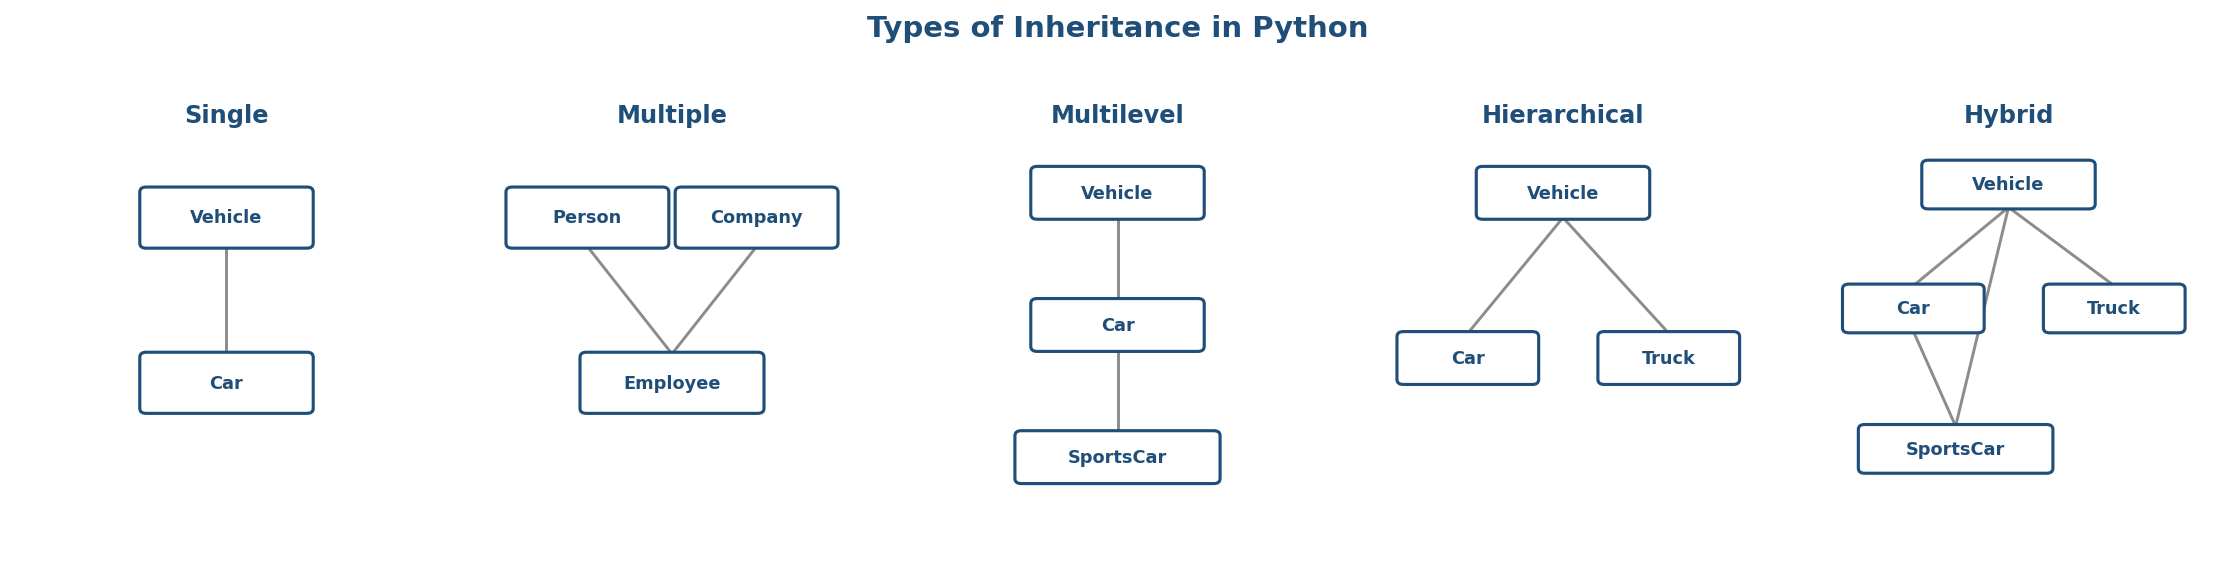

## Single Inheritance

One child, one parent — the simplest case.

In [ ]:
class Vehicle:

    def vehicle_info(self):

        print('Inside Vehicle class')



class Car(Vehicle):

    def car_info(self):

        print('Inside Car class')



car = Car()

car.vehicle_info()   # inherited from Vehicle

car.car_info()       # defined directly on Car

## Multiple Inheritance

One child inherits from SEVERAL parent classes at once — it gets the combined members of all of them.

In [ ]:
class Person:

    def person_info(self, name, age):

        print('Inside Person class')

        print('Name:', name, 'Age:', age)



class Company:

    def company_info(self, company_name, location):

        print('Inside Company class')

        print('Name:', company_name, 'location:', location)



class Employee(Person, Company):

    def employee_info(self, salary, skill):

        print('Inside Employee class')

        print('Salary:', salary, 'Skill:', skill)



emp = Employee()

emp.person_info('Jessa', 28)

emp.company_info('Google', 'Atlanta')

emp.employee_info(12000, 'Machine Learning')

## Multilevel Inheritance

A CHAIN of classes — A is the parent of B, B is the parent of C, so C transitively inherits from both B AND A.

In [ ]:
class Vehicle:

    def vehicle_info(self):

        print('Inside Vehicle class')



class Car(Vehicle):

    def car_info(self):

        print('Inside Car class')



class SportsCar(Car):

    def sports_car_info(self):

        print('Inside SportsCar class')



s_car = SportsCar()

s_car.vehicle_info()      # from Vehicle (grandparent)

s_car.car_info()          # from Car (parent)

s_car.sports_car_info()   # defined directly on SportsCar

## Hierarchical Inheritance

ONE parent class, MULTIPLE independent children — the reverse shape of multiple inheritance.

In [ ]:
class Vehicle:

    def info(self):

        print("This is Vehicle")



class Car(Vehicle):

    def car_info(self, name):

        print("Car name is:", name)



class Truck(Vehicle):

    def truck_info(self, name):

        print("Truck name is:", name)



obj1 = Car()

obj1.info()

obj1.car_info('BMW')



obj2 = Truck()

obj2.info()

obj2.truck_info('Ford')

## Hybrid Inheritance

Any COMBINATION of the above shapes in one class hierarchy — here, `Vehicle` -> `Car`/`Truck` is hierarchical, and `SportsCar(Car, Vehicle)` is ALSO multiple inheritance layered on top.

In [ ]:
class Vehicle:

    def vehicle_info(self):

        print("Inside Vehicle class")



class Car(Vehicle):

    def car_info(self):

        print("Inside Car class")



class Truck(Vehicle):

    def truck_info(self):

        print("Inside Truck class")



class SportsCar(Car, Vehicle):

    def sports_car_info(self):

        print("Inside SportsCar class")



s_car = SportsCar()

s_car.vehicle_info()

s_car.car_info()

s_car.sports_car_info()

## The `super()` Function

`super()` returns a temporary proxy for the PARENT class, letting a child class call a parent's method WITHOUT hardcoding the parent's name directly. This matters because:

1. You never need to remember or repeat the exact parent class name.
2. It works cleanly with both single and multiple inheritance.
3. It avoids duplicating the parent's logic — genuine code reuse.

In [ ]:
class Company:

    def company_name(self):

        return 'Google'



class Employee(Company):

    def info(self):

        c_name = super().company_name()   # calls the PARENT's method, no hardcoded class name

        print("Jessa works at", c_name)



emp = Employee()

emp.info()

`super()` is especially valuable inside `__init__`, letting a child class extend (rather than completely rewrite) its parent's initialization logic:

In [ ]:
class Vehicle:

    def __init__(self, name, price):

        self.name = name

        self.price = price



class Car(Vehicle):

    def __init__(self, name, price, doors):

        super().__init__(name, price)   # let the parent handle name/price

        self.doors = doors              # Car adds only what's genuinely new



    def info(self):

        print(self.name, self.price, f"{self.doors} doors")



c = Car("BMW X1", 35000, 4)

c.info()

## `issubclass()`

Checks whether one class is a subclass of another (or one of several, if given a tuple) — returns `True`/`False`.

In [ ]:
class Company:

    def fun1(self):

        print("Inside parent class")



class Employee(Company):

    def fun2(self):

        print("Inside child class.")



class Player:

    def fun3(self):

        print("Inside Player class.")



print(issubclass(Employee, Company))

print(issubclass(Employee, list))

print(issubclass(Player, Company))

print(issubclass(Employee, (list, Company)))

print(issubclass(Company, (list, Company)))

## Method Overriding

When a child class defines a method with the SAME name as one in its parent, the child's version REPLACES (overrides) the parent's for objects of that child class.

In [ ]:
class Vehicle:

    def max_speed(self):

        print("max speed is 100 Km/Hour")



class Car(Vehicle):

    def max_speed(self):   # overrides Vehicle's version

        print("max speed is 200 Km/Hour")



car = Car()

car.max_speed()   # calls Car's version, NOT Vehicle's

An overriding method can still choose to call the ORIGINAL parent version too (via `super()`) and add to it, rather than fully replacing it — the best of both worlds when you want to extend rather than completely replace parent behavior.

In [ ]:
class Vehicle:

    def max_speed(self):

        print("Base max speed is 100 Km/Hour")



class Car(Vehicle):

    def max_speed(self):

        super().max_speed()   # still runs the parent's version first

        print("Car's actual max speed is 200 Km/Hour")



car = Car()

car.max_speed()

## Method Resolution Order (MRO)

When a method could plausibly come from more than one class (common in multiple inheritance), **MRO** is the exact order Python searches: the object's OWN class first, then parent classes in the order listed, LEFT TO RIGHT. You can inspect this order directly with `.mro()` or the `__mro__` attribute.

In [ ]:
class A:

    def process(self):

        print("In class A")



class B(A):

    def process(self):

        print("In class B")



class C(B, A):

    def process(self):

        print("In class C")



c1 = C()

c1.process()

print(C.mro())

Here `process()` is defined in all THREE classes — `C.process()` runs because Python finds it directly on `C` first, before ever needing to look further up the chain. The printed MRO list shows the full search order Python WOULD follow if `C` hadn't defined its own version: `C` -> `B` -> `A` -> `object` (every class ultimately inherits from the built-in `object`).

In [ ]:
# A case where MRO's left-to-right rule actually determines the outcome:

class X:

    def greet(self):

        print("Hello from X")



class Y:

    def greet(self):

        print("Hello from Y")



class Z(X, Y):   # X listed FIRST

    pass          # Z doesn't define greet() itself



z = Z()

z.greet()          # X wins - it's listed first in Z(X, Y)

print(Z.mro())

## Summary

- Inheritance lets a child class reuse a parent's members — the core code-reuse mechanism in OOP.
- Five shapes: **single** (1 parent, 1 child), **multiple** (many parents, 1 child), **multilevel** (a chain), **hierarchical** (1 parent, many children), **hybrid** (any combination).
- `super()` calls a parent's method without hardcoding its name — essential for extending (not just replacing) `__init__` and other methods.
- `issubclass(cls, classinfo)` checks the class relationship directly.
- **Method overriding**: a child's method with the same name replaces the parent's, for objects of that child class.
- **MRO** (Method Resolution Order) determines which class's version of a method actually runs when multiple candidates exist — own class first, then parents left-to-right, inspectable via `.mro()`.

## Practice Exercises

1. Create a single-inheritance hierarchy `Animal` -> `Bird`, where `Bird` overrides a `move()` method from `Animal` (e.g. `"walks"` vs `"flies"`).
2. Create a multilevel hierarchy `Shape` -> `Polygon` -> `Rectangle`, where each level adds one new method, and confirm a `Rectangle` object can call methods from ALL three levels.
3. Using `super().__init__()`, create a `Person` class with `name`/`age`, and a `Student` subclass that adds `school`, calling the parent constructor rather than repeating its logic.
4. Create two classes `Flyer` and `Swimmer`, each with their own method, then a `Duck` class using multiple inheritance from both — call both inherited methods on a `Duck` instance.
5. Create three classes `A`, `B(A)`, `C(A)`, `D(B, C)` (the 'diamond' inheritance shape), print `D.mro()`, and explain in a comment which class's version of a same-named method in `B` and `C` would win on a `D` object.

### Exercise 1 solution

In [ ]:
class Animal:

    def move(self):

        print("This animal moves somehow.")



class Bird(Animal):

    def move(self):

        print("This bird flies.")



Animal().move()

Bird().move()

### Exercise 2 solution

In [ ]:
class Shape:

    def describe(self):

        print("I am a shape.")



class Polygon(Shape):

    def sides(self):

        print("I have straight sides.")



class Rectangle(Polygon):

    def right_angles(self):

        print("All my angles are 90 degrees.")



r = Rectangle()

r.describe()

r.sides()

r.right_angles()

### Exercise 3 solution

In [ ]:
class Person:

    def __init__(self, name, age):

        self.name = name

        self.age = age



class Student(Person):

    def __init__(self, name, age, school):

        super().__init__(name, age)

        self.school = school



    def info(self):

        print(f"{self.name}, {self.age}, studies at {self.school}")



s = Student("Priya", 20, "MIT")

s.info()

### Exercise 4 solution

In [ ]:
class Flyer:

    def fly(self):

        print("I can fly!")



class Swimmer:

    def swim(self):

        print("I can swim!")



class Duck(Flyer, Swimmer):

    pass



d = Duck()

d.fly()

d.swim()

### Exercise 5 solution

In [ ]:
class A:

    def process(self):

        print("A")



class B(A):

    def process(self):

        print("B")



class C(A):

    def process(self):

        print("C")



class D(B, C):

    pass



print([cls.__name__ for cls in D.mro()])

D().process()

# B's process() wins on a D object: D's MRO is D -> B -> C -> A -> object,

# so Python finds B's process() before ever reaching C's, since B is listed

# first in 'class D(B, C)' and MRO always searches left to right.